# Bloom Filter

## Learning Objectives

1. **Define** the Bloom filter as a space-efficient approximate set membership structure
2. **Prove** that Bloom filters have no false negatives
3. **Derive** the false positive rate formula and optimal parameter choices
4. **Implement** a Bloom filter with configurable FP rate
5. **Identify** stream applications: URL deduplication, spam filtering, cache lookups


## Problem Statement

### Stream Filtering

A web crawler needs to avoid re-visiting already-seen URLs. With billions of URLs, storing the complete set requires terabytes. We need a compact data structure that answers: "Have I seen this URL before?"

**Requirements:**
- No false negatives: if we saw URL $u$, we must always report "seen"
- Small false positive rate: occasionally reporting "seen" for a new URL is acceptable (we just skip it)
- Sub-linear space in the number of elements

### Bloom Filter Guarantee

A Bloom filter with $m$ bits and $k$ hash functions over $n$ elements:
- **Never** returns False for an element that was inserted (no false negatives)
- Returns True for non-inserted elements with probability $\approx (1 - e^{-kn/m})^k$ (tunable false positive rate)


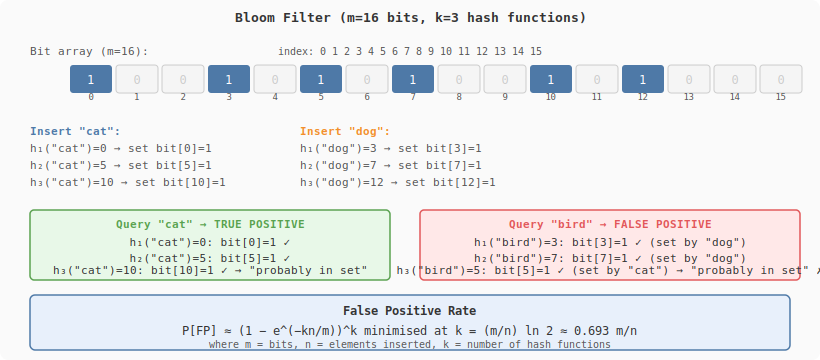

In [1]:
from IPython.display import SVG, display

svg = '''
<svg xmlns="http://www.w3.org/2000/svg" width="820" height="360" font-family="monospace" font-size="12">
  <rect width="820" height="360" fill="#fafafa" rx="8"/>
  <defs><marker id="arr" markerWidth="8" markerHeight="6" refX="7" refY="3" orient="auto"><polygon points="0 0,8 3,0 6" fill="#999"/></marker></defs>

  <text x="410" y="22" text-anchor="middle" fill="#333" font-size="13" font-weight="bold">Bloom Filter (m=16 bits, k=3 hash functions)</text>

  <!-- Bit array -->
  <text x="30" y="55" fill="#555" font-size="11">Bit array (m=16):</text>
  <text x="410" y="55" text-anchor="middle" fill="#555" font-size="10">index:  0  1  2  3  4  5  6  7  8  9  10  11  12  13  14  15</text>

  <!-- bit cells (after inserting "cat" and "dog") -->
  <rect x="70"  y="65" width="42" height="28" rx="3" fill="#4e79a7"/><text x="91"  y="84" text-anchor="middle" fill="white" font-size="12">1</text><text x="91"  y="100" text-anchor="middle" fill="#555" font-size="9">0</text>
  <rect x="116" y="65" width="42" height="28" rx="3" fill="#f5f5f5" stroke="#ccc"/><text x="137" y="84" text-anchor="middle" fill="#ccc" font-size="12">0</text><text x="137" y="100" text-anchor="middle" fill="#555" font-size="9">1</text>
  <rect x="162" y="65" width="42" height="28" rx="3" fill="#f5f5f5" stroke="#ccc"/><text x="183" y="84" text-anchor="middle" fill="#ccc" font-size="12">0</text><text x="183" y="100" text-anchor="middle" fill="#555" font-size="9">2</text>
  <rect x="208" y="65" width="42" height="28" rx="3" fill="#4e79a7"/><text x="229" y="84" text-anchor="middle" fill="white" font-size="12">1</text><text x="229" y="100" text-anchor="middle" fill="#555" font-size="9">3</text>
  <rect x="254" y="65" width="42" height="28" rx="3" fill="#f5f5f5" stroke="#ccc"/><text x="275" y="84" text-anchor="middle" fill="#ccc" font-size="12">0</text><text x="275" y="100" text-anchor="middle" fill="#555" font-size="9">4</text>
  <rect x="300" y="65" width="42" height="28" rx="3" fill="#4e79a7"/><text x="321" y="84" text-anchor="middle" fill="white" font-size="12">1</text><text x="321" y="100" text-anchor="middle" fill="#555" font-size="9">5</text>
  <rect x="346" y="65" width="42" height="28" rx="3" fill="#f5f5f5" stroke="#ccc"/><text x="367" y="84" text-anchor="middle" fill="#ccc" font-size="12">0</text><text x="367" y="100" text-anchor="middle" fill="#555" font-size="9">6</text>
  <rect x="392" y="65" width="42" height="28" rx="3" fill="#4e79a7"/><text x="413" y="84" text-anchor="middle" fill="white" font-size="12">1</text><text x="413" y="100" text-anchor="middle" fill="#555" font-size="9">7</text>
  <rect x="438" y="65" width="42" height="28" rx="3" fill="#f5f5f5" stroke="#ccc"/><text x="459" y="84" text-anchor="middle" fill="#ccc" font-size="12">0</text><text x="459" y="100" text-anchor="middle" fill="#555" font-size="9">8</text>
  <rect x="484" y="65" width="42" height="28" rx="3" fill="#f5f5f5" stroke="#ccc"/><text x="505" y="84" text-anchor="middle" fill="#ccc" font-size="12">0</text><text x="505" y="100" text-anchor="middle" fill="#555" font-size="9">9</text>
  <rect x="530" y="65" width="42" height="28" rx="3" fill="#4e79a7"/><text x="551" y="84" text-anchor="middle" fill="white" font-size="12">1</text><text x="551" y="100" text-anchor="middle" fill="#555" font-size="9">10</text>
  <rect x="576" y="65" width="42" height="28" rx="3" fill="#f5f5f5" stroke="#ccc"/><text x="597" y="84" text-anchor="middle" fill="#ccc" font-size="12">0</text><text x="597" y="100" text-anchor="middle" fill="#555" font-size="9">11</text>
  <rect x="622" y="65" width="42" height="28" rx="3" fill="#4e79a7"/><text x="643" y="84" text-anchor="middle" fill="white" font-size="12">1</text><text x="643" y="100" text-anchor="middle" fill="#555" font-size="9">12</text>
  <rect x="668" y="65" width="42" height="28" rx="3" fill="#f5f5f5" stroke="#ccc"/><text x="689" y="84" text-anchor="middle" fill="#ccc" font-size="12">0</text><text x="689" y="100" text-anchor="middle" fill="#555" font-size="9">13</text>
  <rect x="714" y="65" width="42" height="28" rx="3" fill="#f5f5f5" stroke="#ccc"/><text x="735" y="84" text-anchor="middle" fill="#ccc" font-size="12">0</text><text x="735" y="100" text-anchor="middle" fill="#555" font-size="9">14</text>
  <rect x="760" y="65" width="42" height="28" rx="3" fill="#f5f5f5" stroke="#ccc"/><text x="781" y="84" text-anchor="middle" fill="#ccc" font-size="12">0</text><text x="781" y="100" text-anchor="middle" fill="#555" font-size="9">15</text>

  <!-- Insert "cat": h1=0, h2=5, h3=10 -->
  <text x="30" y="135" fill="#4e79a7" font-size="11" font-weight="bold">Insert "cat":</text>
  <text x="30" y="152" fill="#555" font-size="11">h₁("cat")=0  →  set bit[0]=1</text>
  <text x="30" y="169" fill="#555" font-size="11">h₂("cat")=5  →  set bit[5]=1</text>
  <text x="30" y="186" fill="#555" font-size="11">h₃("cat")=10 →  set bit[10]=1</text>

  <!-- Insert "dog": h1=3, h2=7, h3=12 -->
  <text x="300" y="135" fill="#f28e2b" font-size="11" font-weight="bold">Insert "dog":</text>
  <text x="300" y="152" fill="#555" font-size="11">h₁("dog")=3  →  set bit[3]=1</text>
  <text x="300" y="169" fill="#555" font-size="11">h₂("dog")=7  →  set bit[7]=1</text>
  <text x="300" y="186" fill="#555" font-size="11">h₃("dog")=12 →  set bit[12]=1</text>

  <!-- Query "cat" -->
  <rect x="30" y="210" width="360" height="70" rx="4" fill="#e8f8e8" stroke="#59a14f" stroke-width="1.5"/>
  <text x="210" y="228" text-anchor="middle" fill="#59a14f" font-size="11" font-weight="bold">Query "cat" → TRUE POSITIVE</text>
  <text x="210" y="246" text-anchor="middle" fill="#333" font-size="11">h₁("cat")=0: bit[0]=1 ✓</text>
  <text x="210" y="262" text-anchor="middle" fill="#333" font-size="11">h₂("cat")=5: bit[5]=1 ✓</text>
  <text x="210" y="274" text-anchor="middle" fill="#333" font-size="11">h₃("cat")=10: bit[10]=1 ✓  → "probably in set"</text>

  <!-- Query "bird" (false positive) -->
  <rect x="420" y="210" width="380" height="70" rx="4" fill="#ffe8e8" stroke="#e15759" stroke-width="1.5"/>
  <text x="610" y="228" text-anchor="middle" fill="#e15759" font-size="11" font-weight="bold">Query "bird" → FALSE POSITIVE</text>
  <text x="610" y="246" text-anchor="middle" fill="#333" font-size="11">h₁("bird")=3: bit[3]=1 ✓  (set by "dog")</text>
  <text x="610" y="262" text-anchor="middle" fill="#333" font-size="11">h₂("bird")=7: bit[7]=1 ✓  (set by "dog")</text>
  <text x="610" y="274" text-anchor="middle" fill="#333" font-size="11">h₃("bird")=5: bit[5]=1 ✓  (set by "cat")  → "probably in set" ✗</text>

  <!-- Formula -->
  <rect x="30" y="295" width="760" height="55" rx="5" fill="#e8f0fb" stroke="#4e79a7" stroke-width="1.5"/>
  <text x="410" y="315" text-anchor="middle" fill="#333" font-size="12" font-weight="bold">False Positive Rate</text>
  <text x="410" y="335" text-anchor="middle" fill="#333" font-size="12">P[FP] ≈ (1 − e^(−kn/m))^k     minimised at k = (m/n) ln 2 ≈ 0.693 m/n</text>
  <text x="410" y="348" text-anchor="middle" fill="#555" font-size="10">where m = bits, n = elements inserted, k = number of hash functions</text>
</svg>
'''

display(SVG(svg))


## Derivation

### Insert Operation

For each inserted element $x$ and hash function $h_i$ ($i = 1, \ldots, k$): set $\text{bits}[h_i(x)] = 1$.

Each hash function maps $x$ to a position in $[0, m)$, chosen (approximately) uniformly at random.

### Query Operation

For element $x$: return "in set" iff $\text{bits}[h_i(x)] = 1$ for **all** $i = 1, \ldots, k$.

Since inserting $x$ sets all $k$ positions, a true element always returns "in set". $\square$ (No false negatives.)

### False Positive Rate

After inserting $n$ elements, the probability that a **specific bit** remains 0:

$$P[\text{bit} = 0] = \left(1 - \frac{1}{m}\right)^{kn} \approx e^{-kn/m}$$

The probability that a non-inserted element $y$ causes all $k$ queried bits to be 1 (false positive):

$$P[\text{FP}] = \left(1 - e^{-kn/m}\right)^k$$

### Optimal Parameters

Minimise $P[\text{FP}]$ over $k$ (given fixed $m$, $n$):

$$k^* = \frac{m}{n} \ln 2 \approx 0.693 \frac{m}{n}$$

The corresponding optimal FP rate:

$$P[\text{FP}]^* = \left(\frac{1}{2}\right)^{k^*} \approx 0.6185^{m/n}$$

For FP rate $p$, the required bit array size:

$$m = -\frac{n \ln p}{(\ln 2)^2}$$

For $p = 1\%$ and $n = 10^9$: $m \approx 9.6 \times 10^9$ bits ≈ **1.2 GB** vs. ~**8 GB** for a hash set.


## Algorithm Steps

### Build Phase

1. Initialise bit array of $m$ zeros
2. For each element $x$ to insert: for $i = 1, \ldots, k$: set $\text{bits}[h_i(x)] = 1$

### Query Phase

For element $y$: return True iff $\text{bits}[h_i(y)] = 1$ for all $i = 1, \ldots, k$

### Parameter Selection

Given $n$ (expected elements) and desired FP rate $p$:
1. Compute $m = -n \ln p / (\ln 2)^2$ (round up)
2. Compute $k = (m/n) \ln 2$ (round to nearest integer)


In [2]:
import math
import mmh3  # pip install mmh3  (MurmurHash3)
import numpy as np


class BloomFilter:
    """
    Bloom Filter for approximate set membership.

    Inputs
    ------
    n_elements    : int — expected number of elements to insert
    false_pos_rate: float — desired false positive probability
    """

    def __init__(self, n_elements, false_pos_rate=0.01):
        # Optimal bit array size
        self.m = self._optimal_m(n_elements, false_pos_rate)
        # Optimal number of hash functions
        self.k = self._optimal_k(self.m, n_elements)
        self.bits = np.zeros(self.m, dtype=bool)
        self.n_inserted = 0

        print(f"Bloom filter: m={self.m} bits ({self.m/8/1024:.1f} KB), k={self.k} hash functions")
        print(f"  Theoretical FP rate at n={n_elements}: {self.fp_rate(n_elements):.4f}")

    @staticmethod
    def _optimal_m(n, p):
        return max(1, int(-n * math.log(p) / math.log(2)**2))

    @staticmethod
    def _optimal_k(m, n):
        return max(1, round(m / n * math.log(2)))

    def _hashes(self, item):
        """Generate k hash values for item using double hashing."""
        h1 = mmh3.hash(str(item), seed=0, signed=False)
        h2 = mmh3.hash(str(item), seed=1, signed=False)
        return [(h1 + i * h2) % self.m for i in range(self.k)]

    def add(self, item):
        for pos in self._hashes(item):
            self.bits[pos] = True
        self.n_inserted += 1

    def contains(self, item):
        """
        Returns True if item is probably in the set.
        Never returns False for items that were added (no false negatives).
        May return True for items not added (false positives).
        """
        return all(self.bits[pos] for pos in self._hashes(item))

    def fp_rate(self, n=None):
        n = n or self.n_inserted
        return (1 - math.exp(-self.k * n / self.m)) ** self.k


# ── Demo: web crawler URL deduplication ───────────────────────────────────────
try:
    bf = BloomFilter(n_elements=10_000, false_pos_rate=0.01)

    # Insert 1000 "seen" URLs
    seen_urls = [f"https://example.com/page/{i}" for i in range(1000)]
    for url in seen_urls:
        bf.add(url)

    # Test true negatives and false positives on 1000 new URLs
    new_urls = [f"https://other.com/page/{i}" for i in range(1000)]
    fps = sum(1 for url in new_urls if bf.contains(url))

    print(f"\nInserted {bf.n_inserted} URLs")
    print(f"Actual FP rate on 1000 new URLs: {fps/1000:.4f}")
    print(f"Theoretical FP rate: {bf.fp_rate():.4f}")
    print(f"True positives (all seen URLs found): {sum(bf.contains(u) for u in seen_urls)}/1000")

except ImportError:
    print("Install mmh3: pip install mmh3")
    print("\nFallback demo using Python's hash():")

    class SimpleBloomFilter:
        def __init__(self, m, k):
            self.m, self.k = m, k
            self.bits = [False] * m
        def _hashes(self, item):
            return [hash((item, i)) % self.m for i in range(self.k)]
        def add(self, item):
            for p in self._hashes(item): self.bits[p] = True
        def contains(self, item):
            return all(self.bits[p] for p in self._hashes(item))

    bf = SimpleBloomFilter(m=50000, k=7)
    seen = {f"page_{i}" for i in range(1000)}
    for url in seen: bf.add(url)
    new = [f"other_{i}" for i in range(1000)]
    fps = sum(1 for u in new if bf.contains(u))
    tps = sum(1 for u in seen if bf.contains(u))
    print(f"FP rate: {fps/1000:.4f}, TP rate: {tps/1000:.4f}")


Bloom filter: m=95850 bits (11.7 KB), k=7 hash functions
  Theoretical FP rate at n=10000: 0.0100

Inserted 1000 URLs
Actual FP rate on 1000 new URLs: 0.0000
Theoretical FP rate: 0.0000
True positives (all seen URLs found): 1000/1000
